# Optuna, Registro de experimentos y Regularización

In [3]:
import mlflow
import dagshub
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import RMSprop, SGD, Adam
from tensorflow.keras.regularizers import l1, l2, l1_l2
from keras.callbacks import ModelCheckpoint, EarlyStopping
import variables as var
import optuna
from optuna_integration.mlflow import MLflowCallback
import matplotlib.pyplot as plt

2026-09-14 20:29:01.580839: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-14 20:29:01.741047: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789439341.803520   11555 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789439341.828210   11555 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-14 20:29:01.974813: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [68]:
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))


GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cargamos la base de datos

In [8]:
dataset = mnist.load_data()
(x_train, y_train), (x_test, y_test) = dataset
#normalizamos los datos
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0
#los ponemos en la forma de entrada de la red
x_trainv = x_train.reshape(x_train.shape[0], 784, 1)
x_testv = x_test.reshape(x_test.shape[0], 784, 1)
#hacemos one-hot encoding
num_classes = 10
y_trainc = keras.utils.to_categorical(y_train, num_classes)
y_testc = keras.utils.to_categorical(y_test, num_classes)

indices_sub_train = np.random.choice(x_trainv.shape[0], size=10000, replace=False)
indices_sub_test = np.random.choice(x_testv.shape[0], size=1000, replace=False)
x_train_sub = x_trainv[indices_sub_train]
y_train_sub = y_trainc[indices_sub_train]
x_test_sub = x_testv[indices_sub_test]
y_test_sub = y_testc[indices_sub_test]


## Construimos los modelos

In [70]:
def construccion_modelo(trial):
    model = Sequential()
    model.add(Flatten(input_shape=(784, 1)))

    n_layers = trial.suggest_int("n_layers", 1, 8)
    activations = ["tanh", "sigmoid", "relu"]

    for i in range(n_layers):
        n_units = trial.suggest_int(f"n_units_l{i}", 32, 256)
        activation = trial.suggest_categorical(f"activation_{i}", activations)
        model.add(Dense(n_units, activation=activation))

    model.add(Dense(10, activation='softmax'))
    
    lr = trial.suggest_float("lr", 1e-6, 1e-1, log=True)
    #mlflow.log_param("lr", lr)
    optimizer_options = ["sgd", "adam", "rmsprop"]
    optimizer_selected = trial.suggest_categorical("optimizer", optimizer_options)
    #mlflow.log_param("optimizer", optimizer_selected)

    if optimizer_selected == "adam":
        inv_b1 = trial.suggest_float("inv_beta_1", 1/0.99, 1/0.5, log=True)
        beta_1 = 1.0 / inv_b1
        
        inv_b2 = trial.suggest_float("inv_beta_2", 1/0.999, 1/0.5, log=True)
        beta_2 = 1.0 / inv_b2

        
        optimizer = Adam(learning_rate=lr, beta_1=beta_1, beta_2=beta_2)
        
    elif optimizer_selected == "sgd":
        optimizer = SGD(learning_rate=lr)
        
    elif optimizer_selected == "rmsprop":
        optimizer = RMSprop(learning_rate=lr)
        
    model.compile(optimizer=optimizer,
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [71]:
def objective(trial):
    epochs = 10
    batch_size = 64
    #mlflow.log_param("epochs", epochs)
    #mlflow.log_param("batch_size", batch_size)
    
    modelo = construccion_modelo(trial)
    
    history = modelo.fit(x_train_sub, y_train_sub, 
               epochs=epochs,
               batch_size=batch_size, 
               verbose=0,
               validation_data=(x_test_sub, y_test_sub))
               
    loss, accuracy = modelo.evaluate(x_test_sub, y_test_sub, verbose=0)
    
    #mlflow.log_metric("final_test_loss", loss)
    #mlflow.log_metric("final_test_accuracy", accuracy)

    return accuracy

## Buscamos al mejor modelo

In [72]:
dagshub.init(repo_name=var.REPO_NAME, repo_owner=var.REPO_OWNER, mlflow=True)
mlflow.tensorflow.autolog()
mlflc = MLflowCallback(
    metric_name="accuracy",   
    mlflow_kwargs={"nested": True},         # Ejecuciones anidadas bajo una ejecución padre del estudio
    create_experiment=True  
)

study = optuna.create_study(
    study_name="Busqueda_de_parametros",
    direction="maximize"
)

study.optimize(objective, n_trials=60, callbacks=[mlflc])

Initialized MLflow to track repo "DRACDARKTIME/Tarea2_OptunaRegularizers"

Repository DRACDARKTIME/Tarea2_OptunaRegularizers initialized!

/tmp/ipykernel_113310/931539885.py:3: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflc = MLflowCallback(
[I 2026-09-14 14:22:55,272] A new study created in memory with name: Busqueda_de_parametros
2026/09/14 14:22:55 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3d50fee3abc141868115e859188270a8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow


2026-09-14 14:22:58.076435: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_176', 140 bytes spill stores, 140 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
🏃 View run amazing-bird-156 at: https://dagshub.com/DRACDARKTIME/Tarea2_OptunaRegularizers.mlflow/#/experiments/1/runs/3d50fee3abc141868115e859188270a8
🧪 View experiment at: https://dagshub.com/DRACDARKTIME/Tarea2_OptunaRegularizers.mlflow/#/experiments/1


...

2026/09/14 16:28:27 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9f4a10dd8225426fb9b22d7d67302d12', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow


2026-09-14 16:28:41.981569: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_51', 32 bytes spill stores, 16 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
🏃 View run thundering-mouse-973 at: https://dagshub.com/DRACDARKTIME/Tarea2_OptunaRegularizers.mlflow/#/experiments/1/runs/9f4a10dd8225426fb9b22d7d67302d12
🧪 View experiment at: https://dagshub.com/DRACDARKTIME/Tarea2_OptunaRegularizers.mlflow/#/experiments/1


[I 2026-09-14 16:30:20,030] Trial 59 finished with value: 0.9660000205039978 and parameters: {'n_layers': 2, 'n_units_l0': 109, 'activation_0': 'tanh', 'n_units_l1': 44, 'activation_1': 'tanh', 'lr': 0.003022218348875124, 'optimizer': 'rmsprop'}. Best is trial 52 with value: 0.9700000286102295.


🏃 View run 59 at: https://dagshub.com/DRACDARKTIME/Tarea2_OptunaRegularizers.mlflow/#/experiments/1/runs/605b1b8b023048f394927534ef7552c6
🧪 View experiment at: https://dagshub.com/DRACDARKTIME/Tarea2_OptunaRegularizers.mlflow/#/experiments/1


In [75]:
best_trial = study.best_trial

print("Mejor intento: ", best_trial)

print("Valor: ", best_trial.value)

print("Hiperparámetros: ", best_trial.params)

Mejor intento:  FrozenTrial(number=52, state=<TrialState.COMPLETE: 1>, values=[0.9700000286102295], datetime_start=datetime.datetime(2026, 9, 14, 16, 13, 56, 443520), datetime_complete=datetime.datetime(2026, 9, 14, 16, 15, 41, 960563), params={'n_layers': 1, 'n_units_l0': 175, 'activation_0': 'tanh', 'lr': 0.010926400304589415, 'optimizer': 'rmsprop'}, user_attrs={}, system_attrs={'tpe:relative_params:0': '{"activation_0": "tanh", "lr": 0.010926400304589415, "n_layers": 1, "n_units_l0": 175, "optimizer": "rmsprop"}'}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=8, log=False, low=1, step=1), 'n_units_l0': IntDistribution(high=256, log=False, low=32, step=1), 'activation_0': CategoricalDistribution(choices=('tanh', 'sigmoid', 'relu')), 'lr': FloatDistribution(high=0.1, log=True, low=1e-06, step=None), 'optimizer': CategoricalDistribution(choices=('sgd', 'adam', 'rmsprop'))}, trial_id=52, value=None)
Valor:  0.9700000286102295
Hiperparámetros:  {'n_layers': 1,

In [ ]:
mlflow.end_run()

🏃 View run upbeat-croc-807 at: https://dagshub.com/DRACDARKTIME/Tarea2_OptunaRegularizers.mlflow/#/experiments/1/runs/13d774f39e6e40fd8bba032130395d0a
🧪 View experiment at: https://dagshub.com/DRACDARKTIME/Tarea2_OptunaRegularizers.mlflow/#/experiments/1


## Ahora escogemos la mejor red y procedemos a entrenarla con regularizadores

In [26]:
BEST_LR     = 0.010926400409589415
BEST_UNITS  = 175
BEST_ACT    = "tanh"
EPOCHS      = 30
BATCH       = 64
L1_VAL      = 1e-5
L2_VAL      = 1e-6
DROPOUT     = 0.3

In [ ]:
from tensorflow.keras.callbacks import Callback

class MLflowEpochLogger(Callback):
    """Registra las métricas de cada época en la run activa de MLflow."""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        # Métricas por época
        mlflow.log_metric("train_loss",     logs.get("loss"),         step=epoch)
        mlflow.log_metric("train_accuracy", logs.get("accuracy"),     step=epoch)
        mlflow.log_metric("val_loss",       logs.get("val_loss"),     step=epoch)
        mlflow.log_metric("val_accuracy",   logs.get("val_accuracy"), step=epoch)

        # gap train-val por época
        if "accuracy" in logs and "val_accuracy" in logs:
            mlflow.log_metric("gap_accuracy",
                              logs["accuracy"] - logs["val_accuracy"],
                              step=epoch)

In [ ]:
def build_model(regularizer=None, dropout=0.0):
    """Reconstruye la mejor red (Trial 52) con regularización opcional."""
    model = Sequential()
    model.add(Flatten(input_shape=(784, 1)))
    model.add(Dense(BEST_UNITS, activation=BEST_ACT,
                    kernel_regularizer=regularizer))
    if dropout > 0:
        model.add(Dropout(dropout))
    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer=RMSprop(learning_rate=BEST_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_and_log(run_name, regularizer=None, dropout=0.0, extra_params=None):
    """Entrena un modelo, lo registra en MLflow (por época) y regresa el history."""
    with mlflow.start_run(run_name=run_name, nested=True):
        mlflow.log_params({
            "optimizer": "rmsprop",
            "learning_rate": BEST_LR,
            "units": BEST_UNITS,
            "activation": BEST_ACT,
            "epochs": EPOCHS,
            "batch_size": BATCH,
            "dropout": dropout,
        })
        if extra_params:
            mlflow.log_params(extra_params)

        model = build_model(regularizer=regularizer, dropout=dropout)

        history = model.fit(
            x_trainv, y_trainc,
            epochs=EPOCHS,
            batch_size=BATCH,
            validation_data=(x_testv, y_testc),
            callbacks=[MLflowEpochLogger()],   # 👈 aquí
            verbose=1,
        )

        mlflow.log_metrics({
            "final_train_acc":  history.history["accuracy"][-1],
            "final_val_acc":    history.history["val_accuracy"][-1],
            "final_train_loss": history.history["loss"][-1],
            "final_val_loss":   history.history["val_loss"][-1],
        })

        # Mejor val_accuracy y su época
        best_val = max(history.history["val_accuracy"])
        best_epoch = history.history["val_accuracy"].index(best_val)
        mlflow.log_metrics({
            "best_val_accuracy": best_val,
            "best_epoch":        best_epoch,
        })

    return history

In [35]:
dagshub.init(repo_name=var.REPO_NAME, repo_owner=var.REPO_OWNER, mlflow=True)
mlflow.set_experiment("Regularizadores_MNIST")

with mlflow.start_run(run_name="Comparativa_Regularizadores"):

    h_base    = train_and_log("Sin_regularizador")

    h_l1      = train_and_log("L1",
                              regularizer=l1(L1_VAL),
                              extra_params={"l1": L1_VAL})

    h_l2      = train_and_log("L2",
                              regularizer=l2(L2_VAL),
                              extra_params={"l2": L2_VAL})

    h_l1l2    = train_and_log("L1_L2",
                              regularizer=l1_l2(l1=L1_VAL, l2=L2_VAL),
                              extra_params={"l1": L1_VAL, "l2": L2_VAL})

    h_do      = train_and_log("Dropout",
                              dropout=DROPOUT,
                              extra_params={"dropout": DROPOUT})

    h_do_l1l2 = train_and_log("Dropout_L1_L2",
                              regularizer=l1_l2(l1=L1_VAL, l2=L2_VAL),
                              dropout=DROPOUT,
                              extra_params={"l1": L1_VAL, "l2": L2_VAL,
                                            "dropout": DROPOUT})

Initialized MLflow to track repo "DRACDARKTIME/Tarea2_OptunaRegularizers"

Repository DRACDARKTIME/Tarea2_OptunaRegularizers initialized!

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8568 - loss: 0.4977 - val_accuracy: 0.9541 - val_loss: 0.1680
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9511 - loss: 0.1697 - val_accuracy: 0.9606 - val_loss: 0.1356
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9616 - loss: 0.1328 - val_accuracy: 0.9580 - val_loss: 0.1532
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9676 - loss: 0.1144 - val_accuracy: 0.9537 - val_loss: 0.1769
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9696 - loss: 0.1007 - val_accuracy: 0.9649 - val_loss: 0.1294
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9737 - loss: 0.0930 - val_accuracy: 0.9654 - val_loss: 0.1255
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9744 - loss: 0.0920 - val_accuracy: 0.9642 - val_loss: 0.1515
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9771 - loss: 0.0814 - val_accura

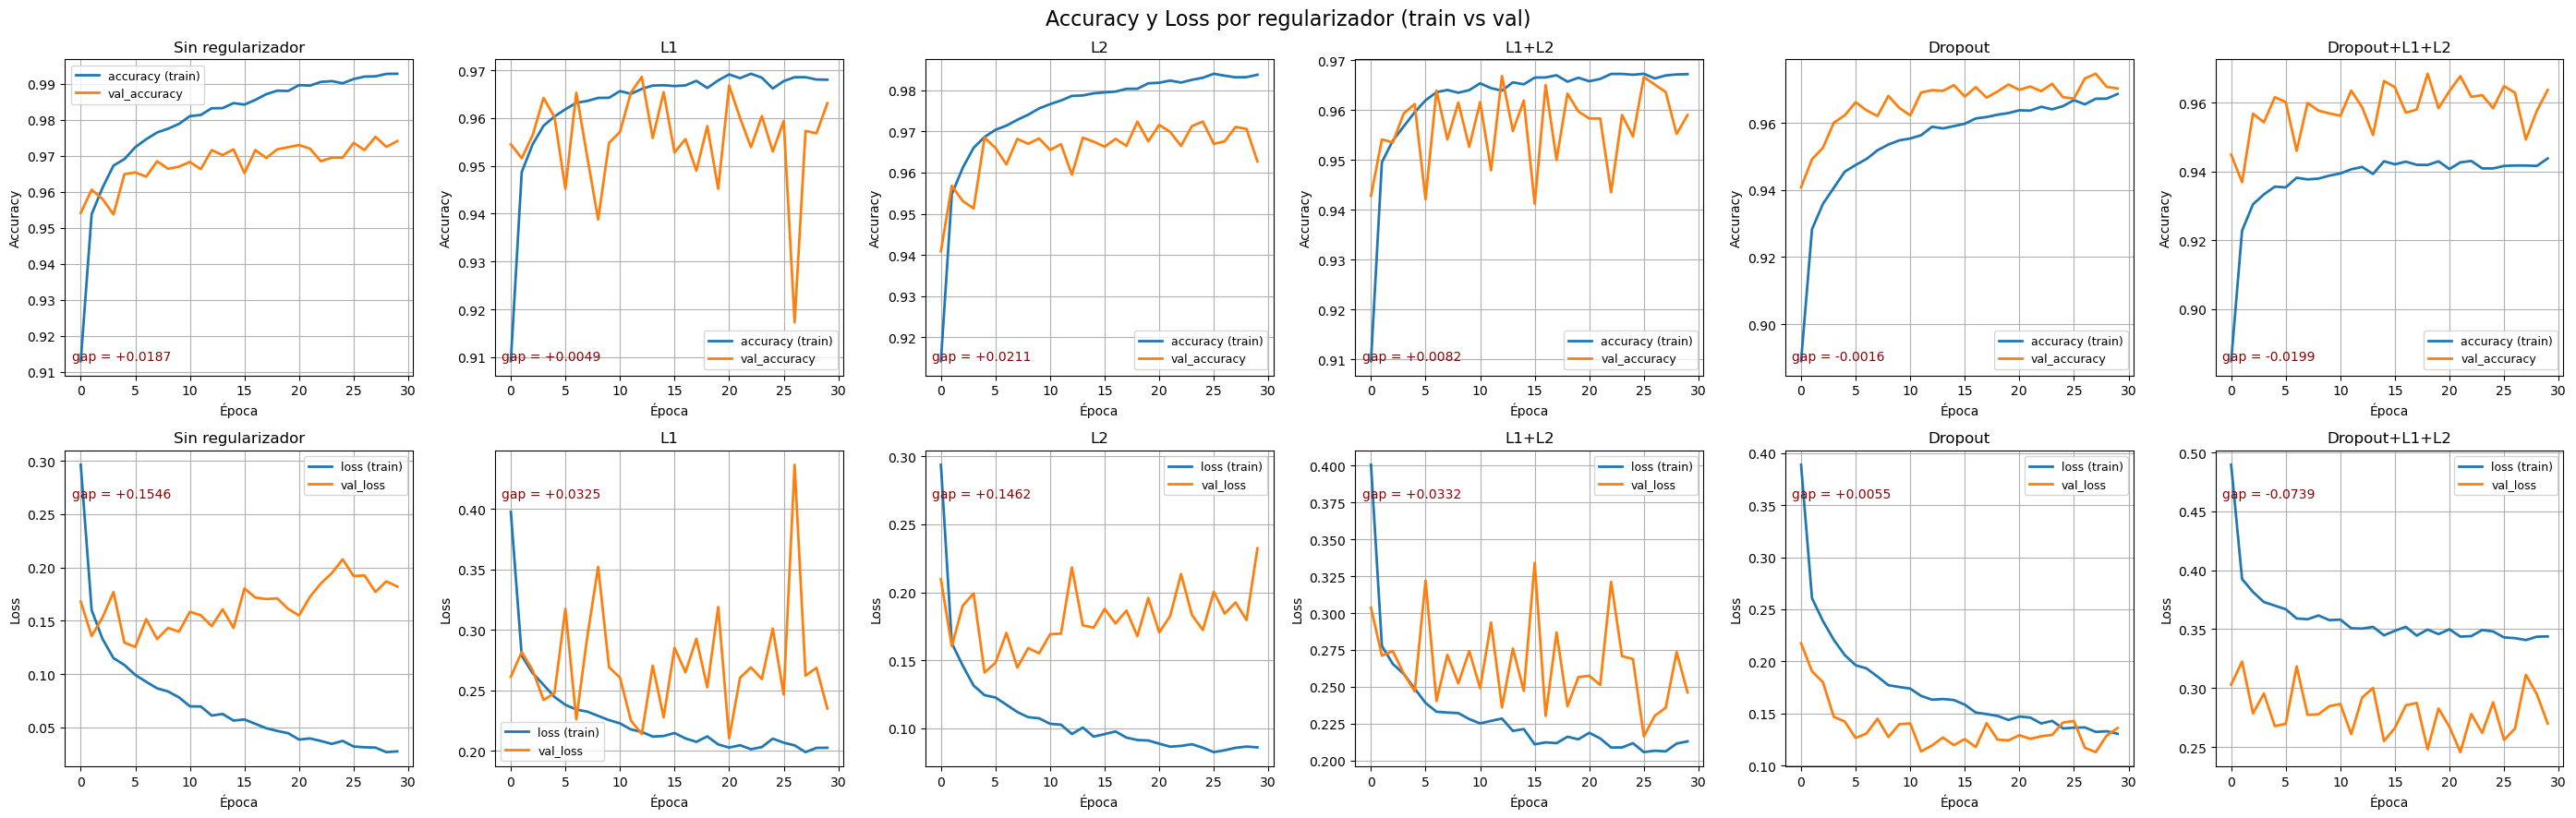

In [36]:
historias = {
    "Sin regularizador": h_base,
    "L1":                h_l1,
    "L2":                h_l2,
    "L1+L2":             h_l1l2,
    "Dropout":           h_do,
    "Dropout+L1+L2":     h_do_l1l2,
}

fig, axes = plt.subplots(2, 6, figsize=(28, 9))

for i, (name, h) in enumerate(historias.items()):
    # --- Fila 0: Accuracy ---
    ax_acc = axes[0, i]
    ax_acc.plot(h.history["accuracy"],     label="accuracy (train)", linewidth=2)
    ax_acc.plot(h.history["val_accuracy"], label="val_accuracy",     linewidth=2)
    ax_acc.set_title(name, fontsize=12)
    ax_acc.set_xlabel("Época")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.grid(True)
    ax_acc.legend(fontsize=9)

    gap_acc = h.history["accuracy"][-1] - h.history["val_accuracy"][-1]
    ax_acc.text(0.02, 0.05, f"gap = {gap_acc:+.4f}",
                transform=ax_acc.transAxes, fontsize=10, color="darkred")

    # --- Fila 1: Loss ---
    ax_loss = axes[1, i]
    ax_loss.plot(h.history["loss"],     label="loss (train)", linewidth=2)
    ax_loss.plot(h.history["val_loss"], label="val_loss",     linewidth=2)
    ax_loss.set_title(name, fontsize=12)
    ax_loss.set_xlabel("Época")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(True)
    ax_loss.legend(fontsize=9)

    gap_loss = h.history["val_loss"][-1] - h.history["loss"][-1]
    ax_loss.text(0.02, 0.85, f"gap = {gap_loss:+.4f}",
                 transform=ax_loss.transAxes, fontsize=10, color="darkred")

plt.suptitle("Accuracy y Loss por regularizador (train vs val)", fontsize=16)
plt.tight_layout()
plt.savefig("regularizadores_grid_full.png", dpi=120, bbox_inches="tight")
plt.show()

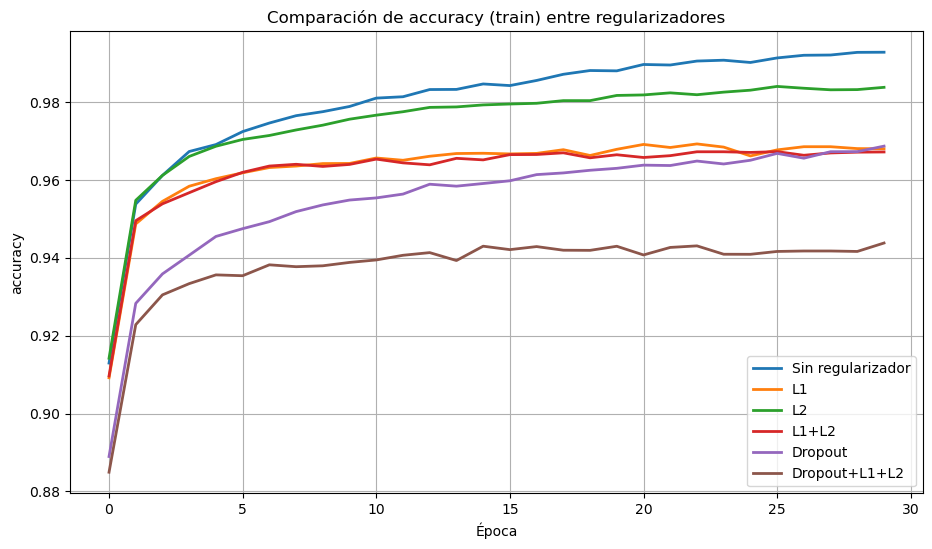

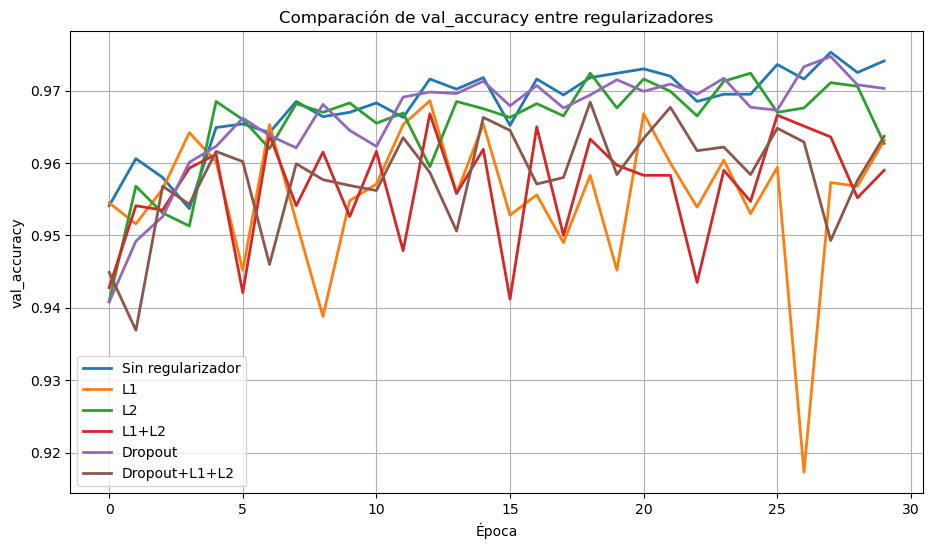

In [37]:

#train_accuracy
plt.figure(figsize=(11, 6))
for name, h in historias.items():
    plt.plot(h.history["accuracy"], label=name, linewidth=2)
plt.title("Comparación de accuracy (train) entre regularizadores")
plt.xlabel("Época")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.savefig("regularizadores_train_acc.png", dpi=120)
plt.show()

#val_accuracy
plt.figure(figsize=(11, 6))
for name, h in historias.items():
    plt.plot(h.history["val_accuracy"], label=name, linewidth=2)
plt.title("Comparación de val_accuracy entre regularizadores")
plt.xlabel("Época")
plt.ylabel("val_accuracy")
plt.legend()
plt.grid(True)
plt.savefig("regularizadores_val_acc.png", dpi=120)
plt.show()


In [38]:
print(f"{'Modelo':<20}{'train_acc':>12}{'val_acc':>12}{'gap':>10}")
print("-" * 54)
for name, h in historias.items():
    tr = h.history["accuracy"][-1]
    va = h.history["val_accuracy"][-1]
    print(f"{name:<20}{tr:>12.4f}{va:>12.4f}{tr - va:>10.4f}")

with mlflow.start_run(run_name="Reporte_graficas"):
    mlflow.log_artifact("regularizadores_grid.png")
    mlflow.log_artifact("regularizadores_val_acc.png")
    mlflow.log_artifact("regularizadores_train_acc.png")

Modelo                 train_acc     val_acc       gap
------------------------------------------------------
Sin regularizador         0.9928      0.9741    0.0187
L1                        0.9680      0.9631    0.0049
L2                        0.9838      0.9627    0.0211
L1+L2                     0.9672      0.9590    0.0082
Dropout                   0.9687      0.9703   -0.0016
Dropout+L1+L2             0.9438      0.9637   -0.0199
🏃 View run Reporte_graficas at: https://dagshub.com/DRACDARKTIME/Tarea2_OptunaRegularizers.mlflow/#/experiments/2/runs/f938d1273c414325b8fe4b0a53ae354e
🧪 View experiment at: https://dagshub.com/DRACDARKTIME/Tarea2_OptunaRegularizers.mlflow/#/experiments/2
